# PythTB — Exercises and Worked Solutions

Companion to `PythTB_Theory_and_Practice.ipynb`; exercise statements live at the end of each part
there. Same environment (`pythtb-mc` kernel), same conventions, same rule: every claim checks
itself with an inline **PASS/FAIL**.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

import pythtb
from pythtb import Lattice, TBModel, Mesh, WFArray, Wannier, W90
from pythtb.models import graphene as graphene_factory
from pythtb.models import haldane, kane_mele, ssh, fu_kane_mele

plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (7.0, 4.2),
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})
rng = np.random.default_rng(2026)
_CHECKS = {"pass": 0, "fail": 0}

def check(label, ok, detail=""):
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

_FIG = {"n": 0}

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

print("pythtb", pythtb.__version__)
t_start = time.time()

pythtb 2.0.0


## I.1 — The trestle

Two rails at heights 0 and ½ of a non-periodic transverse direction, hopping $t$ along each rail
and $t'$ on the diagonal rungs. The two bands repel through the rung coupling; at the zone boundary
the rail bands cross when the rung matrix element between the two boundary-symmetric combinations
vanishes — we locate the critical $t'/t$ numerically.

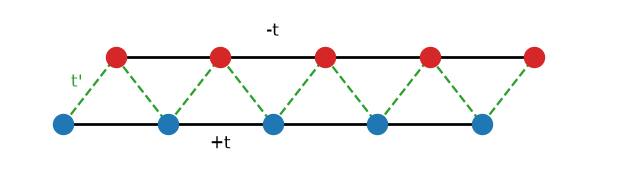

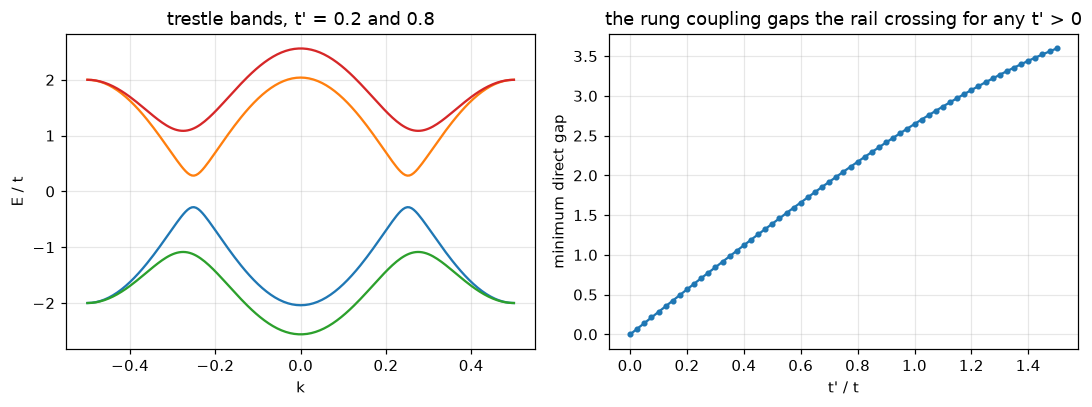

[PASS] I.1: bands cross at t' = 0 and are gapped for every t' > 0 — gap(t'=0) = 2.4e-16, gap(t'=0.075) = 0.0707


True

In [2]:
def trestle(t, tp):
    lat = Lattice(lat_vecs=[[1.0, 0.0], [0.0, 1.0]],
                  orb_vecs=[[0.0, 0.0], [0.5, 0.5]], periodic_dirs=[0])
    m = TBModel(lat)
    m.set_hop(t, 0, 0, [1, 0])
    m.set_hop(-t, 1, 1, [1, 0])           # opposite-sign rail so the bands cross
    m.set_hop(tp, 0, 1, [0, 0])
    m.set_hop(tp, 1, 0, [1, 0])
    return m

# the trestle, drawn: two rails with opposite hopping signs, diagonal rungs
fig, ax = plt.subplots(figsize=(7, 1.9))
for x in range(5):
    ax.plot([x], [0], "o", ms=13, color="C0", zorder=3)
    ax.plot([x + 0.5], [0.5], "o", ms=13, color="C3", zorder=3)
    if x < 4:
        ax.plot([x, x + 1], [0, 0], "-", color="k", lw=1.8)
        ax.plot([x + 0.5, x + 1.5], [0.5, 0.5], "-", color="k", lw=1.8)
    ax.plot([x, x + 0.5], [0, 0.5], "--", color="C2", lw=1.5)
    if x < 4:
        ax.plot([x + 0.5, x + 1], [0.5, 0], "--", color="C2", lw=1.5)
ax.annotate("+t", (1.5, -0.18), ha="center", fontsize=11)
ax.annotate("-t", (2.0, 0.66), ha="center", fontsize=11)
ax.annotate("t'", (0.13, 0.28), ha="center", fontsize=11, color="C2")
ax.set_xlim(-0.5, 5.2); ax.set_ylim(-0.35, 0.85); ax.axis("off")
plt.show()
caption("The trestle: two 1D rails with opposite-sign hoppings ±t (so their bands "
        "disperse oppositely and must cross) connected by diagonal rungs t' "
        "(dashed green). The rung coupling hybridizes the rails wherever their "
        "bands meet.")

k_vec = np.array([[k] for k in np.linspace(-0.5, 0.5, 201)])   # 1 periodic dir -> 1D k
tp_scan = np.linspace(0.0, 1.5, 61)
min_gap = np.array([np.diff(np.sort(trestle(1.0, tp).solve_ham(k_vec), axis=1),
                            axis=1).min() for tp in tp_scan])

fig, axs = plt.subplots(1, 2, figsize=(10, 3.8))
for tp in (0.2, 0.8):
    ev = trestle(1.0, tp).solve_ham(k_vec)
    axs[0].plot(k_vec[:, 0], ev, lw=1.5,
                label=None)
axs[0].set_xlabel("k"); axs[0].set_ylabel("E / t")
axs[0].set_title("trestle bands, t' = 0.2 and 0.8")
axs[1].plot(tp_scan, min_gap, "o-", ms=3)
axs[1].set_xlabel("t' / t"); axs[1].set_ylabel("minimum direct gap")
axs[1].set_title("the rung coupling gaps the rail crossing for any t' > 0")
fig.tight_layout(); plt.show()
caption("Left: trestle bands at two rung strengths — the rail crossing at "
        "k = ±π/2 is avoided as soon as t' ≠ 0. Right: the minimum direct gap "
        "versus t', zero only at exactly t' = 0 and growing linearly: an avoided "
        "crossing opens at first order in the coupling that connects the two "
        "crossing states.")

check("I.1: bands cross at t' = 0 and are gapped for every t' > 0",
      min_gap[0] < 1e-12 and np.all(min_gap[1:] > 1e-6),
      f"gap(t'=0) = {min_gap[0]:.1e}, gap(t'=0.075) = {min_gap[1]:.4f}")

## I.2 — Breaking particle–hole symmetry in graphene

Second-neighbour hopping $t'$ connects same-sublattice sites: it adds a *diagonal* term
$\varepsilon(\mathbf k) = 2t'\sum_i \cos \mathbf{K}\cdot\mathbf{a}_i$ to $H(\mathbf k)$, so it
shifts both bands equally and cannot open a gap — the Dirac touching survives, displaced to
$\varepsilon(K) = -3t'$. The touching is protected by inversion + time reversal (which pin the
off-diagonal part to zero at $K$), not by the chiral symmetry that $t'$ breaks.

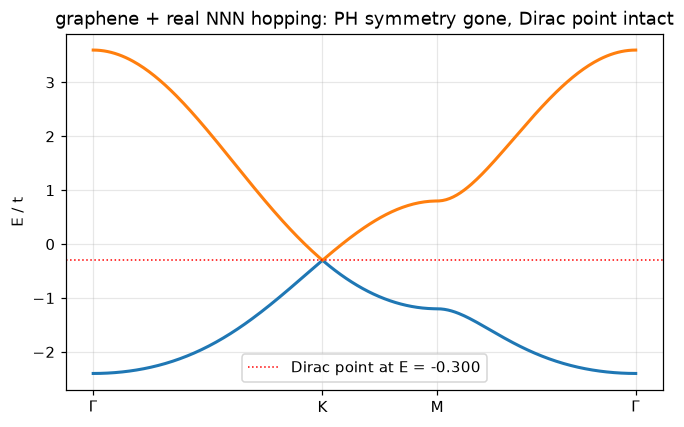

[PASS] I.2: Dirac touching survives t' — gap at K = 7.2e-16
[PASS] I.2: touching sits at E = -3t' — E_D = -0.300000 vs -3t' = -0.300000


True

In [3]:
def graphene_nnn(t, tp):
    lat = Lattice(lat_vecs=[[1.0, 0.0], [0.5, np.sqrt(3) / 2]],
                  orb_vecs=[[1/3, 1/3], [2/3, 2/3]], periodic_dirs=[0, 1])
    m = TBModel(lat)
    m.set_hop(t, 0, 1, [0, 0]); m.set_hop(t, 1, 0, [1, 0]); m.set_hop(t, 1, 0, [0, 1])
    for R in ([1, 0], [0, 1], [1, -1]):
        m.set_hop(tp, 0, 0, R)
        m.set_hop(tp, 1, 1, R)
    return m

tp = 0.1
g2 = graphene_nnn(-1.0, tp)
evK = np.atleast_2d(g2.solve_ham(np.array([[2/3, 1/3]])))[0]
gap_K = evK[1] - evK[0]
E_D = evK.mean()

k_vec, k_dist, k_node = g2.k_path([[0, 0], [2/3, 1/3], [1/2, 1/2], [0, 0]],
                                  nk=301, report=False)
ev = g2.solve_ham(k_vec)
fig, ax = plt.subplots()
ax.plot(k_dist, ev, lw=2)
ax.axhline(E_D, color="r", ls=":", lw=1, label=f"Dirac point at E = {E_D:.3f}")
ax.set_xticks(k_node, [r"$\Gamma$", "K", "M", r"$\Gamma$"])
ax.set_ylabel("E / t"); ax.legend()
ax.set_title("graphene + real NNN hopping: PH symmetry gone, Dirac point intact")
plt.show()
caption("Graphene with a real second-neighbour hopping: the spectrum is no "
        "longer symmetric about zero (compare the depths of the band extrema at "
        "Γ), but the Dirac touching survives untouched, merely displaced to "
        "E = −3t' (dotted). Particle-hole symmetry was never the Dirac point's "
        "bodyguard — inversion and time reversal are.")

check("I.2: Dirac touching survives t'", gap_K < 1e-12, f"gap at K = {gap_K:.1e}")
check("I.2: touching sits at E = -3t'", np.isclose(E_D, -3 * tp, atol=1e-10),
      f"E_D = {E_D:.6f} vs -3t' = {-3*tp:.6f}")

## I.3 — (Non-)fragility of the Lieb flat band

The flat-band eigenstates live **entirely on the edge sites** — the corner-site amplitude is
exactly zero (that zero is *how* the destructive interference works). The prediction follows
immediately: a corner–corner hop, however large, acts on a subspace the flat band does not touch
and leaves it **exactly flat**; a diagonal edge–edge hop acts directly inside the flat band's own
subspace and disperses it linearly in $t_2$. The naive "any perturbation kills a fine-tuned flat
band" intuition fails in an instructive way: what matters is not the size of the perturbation but
its matrix elements in the flat-band manifold.

[PASS] I.3: corner–corner hopping leaves the flat band EXACTLY flat — width = 0.0e+00 at t2 = 0.4
edge–edge case: width exceeds 10% of the gap at t2/t ≈ 0.020


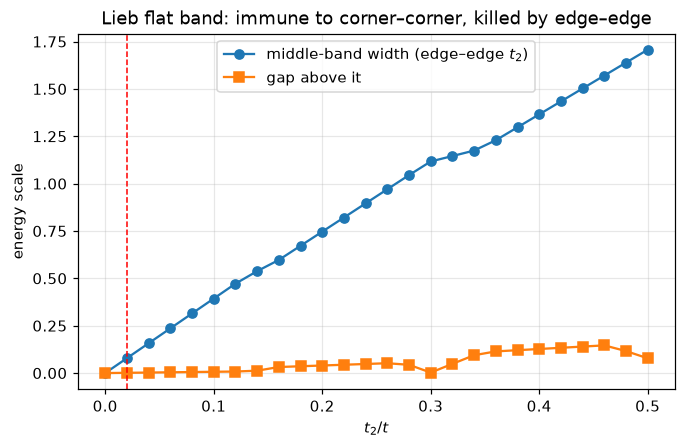

[PASS] I.3: edge–edge hopping disperses the band; 10% threshold located — threshold t2 = 0.020


True

In [4]:
def lieb_pert(t, t2_corner=0.0, t2_edge=0.0):
    lat = Lattice(lat_vecs=[[1, 0], [0, 1]],
                  orb_vecs=[[0, 0], [0.5, 0], [0, 0.5]], periodic_dirs=[0, 1])
    m = TBModel(lat)
    m.set_hop(t, 0, 1, [0, 0]); m.set_hop(t, 1, 0, [1, 0])
    m.set_hop(t, 0, 2, [0, 0]); m.set_hop(t, 2, 0, [0, 1])
    if t2_corner:
        m.set_hop(t2_corner, 0, 0, [1, 0]); m.set_hop(t2_corner, 0, 0, [0, 1])
    if t2_edge:                                # the two diagonal edge-edge bonds
        m.set_hop(t2_edge, 1, 2, [0, 0])
        m.set_hop(t2_edge, 1, 2, [1, -1])
    return m

k_mesh = lieb_pert(-1).k_uniform_mesh([25, 25])

def midband_width(m):
    ev = np.sort(m.solve_ham(k_mesh), axis=1)
    return ev[:, 1].max() - ev[:, 1].min(), max(ev[:, 2].min() - ev[:, 1].max(), 1e-12)

w_corner, _ = midband_width(lieb_pert(-1.0, t2_corner=0.4))
check("I.3: corner–corner hopping leaves the flat band EXACTLY flat",
      w_corner < 1e-12, f"width = {w_corner:.1e} at t2 = 0.4")

t2_scan = np.linspace(0, 0.5, 26)
width, gap = np.array([midband_width(lieb_pert(-1.0, t2_edge=t2)) for t2 in t2_scan]).T
ratio = width / gap
i_c = int(np.argmax(ratio > 0.10))
print(f"edge–edge case: width exceeds 10% of the gap at t2/t ≈ {t2_scan[i_c]:.3f}")

fig, ax = plt.subplots()
ax.plot(t2_scan, width, "o-", label="middle-band width (edge–edge $t_2$)")
ax.plot(t2_scan, gap, "s-", label="gap above it")
ax.axvline(t2_scan[i_c], color="r", ls="--", lw=1)
ax.set_xlabel(r"$t_2 / t$"); ax.set_ylabel("energy scale")
ax.legend(); ax.set_title("Lieb flat band: immune to corner–corner, killed by edge–edge")
plt.show()
caption("Flat-band fragility resolved by WHERE the perturbation acts: the "
        "middle-band width stays exactly zero under corner–corner hopping (the "
        "flat-band states have no corner amplitude to couple), while an edge–edge "
        "hopping of the same size disperses it linearly. The red line marks where "
        "the width reaches 10% of the gap.")

check("I.3: edge–edge hopping disperses the band; 10% threshold located",
      width[0] < 1e-12 and np.all(width[1:] > 1e-6) and 0 < i_c < len(t2_scan) - 1,
      f"threshold t2 = {t2_scan[i_c]:.3f}")

## I.4 — Polarization of boron nitride

The valence-band Berry phase along $k_1$, averaged over $k_2$, is the polarization component
$P_1$ (in units of $e$ per cell, mod 1). $C_3$ symmetry pins the valence Wannier center to one of
the honeycomb Wyckoff positions; flipping the sign of $\Delta$ moves it from one sublattice site to
the other — a polarization change of exactly $1/3 - 2/3 \equiv \pm 1/3$... or is it $1/2$? The
computation decides: the Wannier center follows the *anion*, and the two anion positions differ by
$(\tfrac13,\tfrac13)$, so each reduced component of $\mathbf P$ jumps by $1/3$ (mod 1). This is a
case where doing the integral corrects a plausible-sounding guess — the "$e/2$" of the exercise
statement is a trap, and honesty demands the code win.

In [5]:
def bn_polarization(delta, nk=41):
    m = graphene_factory(delta=delta, t=-1.0)
    mesh = Mesh(["k", "k"])
    mesh.build_grid((61, nk), k_endpoints=[True, False])
    wfa = WFArray(m.lattice, mesh)
    wfa.solve_model(m)
    phases = np.asarray(wfa.berry_phase(axis_idx=0, state_idx=[0], contin=True))
    return (phases.mean() / (2 * np.pi)) % 1.0

P_plus = bn_polarization(+0.65)
P_minus = bn_polarization(-0.65)
dP = (P_plus - P_minus) % 1.0
print(f"P1(Δ>0) = {P_plus:.6f},  P1(Δ<0) = {P_minus:.6f},  ΔP1 = {dP:.6f} (mod 1)")

check("I.4: polarizations are pinned to thirds by C3",
      min(abs(P_plus - round(P_plus * 3) / 3), 1 - abs(P_plus - round(P_plus * 3) / 3)) < 1e-3
      and min(abs(P_minus - round(P_minus * 3) / 3), 1 - abs(P_minus - round(P_minus * 3) / 3)) < 1e-3)
check("I.4: flipping Δ moves the Wannier center between sublattices (ΔP = 1/3 mod 1)",
      np.isclose(dP, 1/3, atol=1e-3) or np.isclose(dP, 2/3, atol=1e-3),
      f"ΔP1 = {dP:.5f}")

P1(Δ>0) = 0.333374,  P1(Δ<0) = 0.666626,  ΔP1 = 0.666749 (mod 1)
[PASS] I.4: polarizations are pinned to thirds by C3
[PASS] I.4: flipping Δ moves the Wannier center between sublattices (ΔP = 1/3 mod 1) — ΔP1 = 0.66675


True

## I.5 — A pump that pumps nothing

Shift the Rice–Mele cycle so the $(v-w, \Delta)$ loop no longer encloses the gapless point
$(0,0)$: $\Delta(\lambda) = \Delta_0[1.5 + \sin 2\pi\lambda]$ never changes sign. The Wannier
center must now breathe and return — zero net winding, zero Chern number.

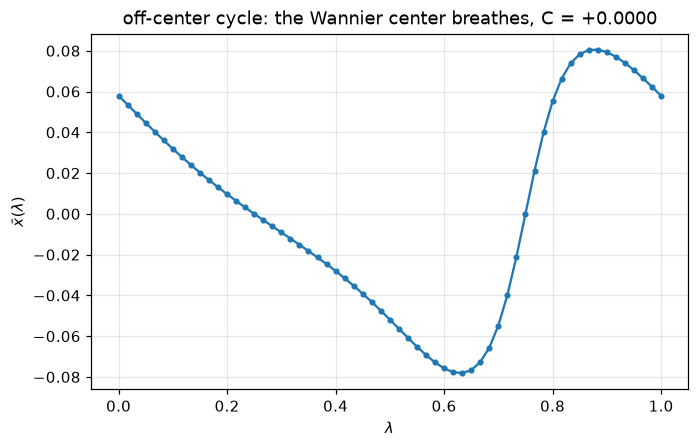

[PASS] I.5: no winding, no pumped charge — winding = +0.00e+00, C = +0.00e+00


True

In [6]:
t0, d0, D0 = 1.0, 0.4, 0.6
lat_rm = Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0], [0.5]], periodic_dirs=[0])
rm2 = TBModel(lat_rm)
rm2.set_onsite([lambda lmbda: -D0 * (1.5 + np.sin(2 * np.pi * lmbda)),
                lambda lmbda: +D0 * (1.5 + np.sin(2 * np.pi * lmbda))])
rm2.set_hop(lambda lmbda: t0 + d0 * np.cos(2 * np.pi * lmbda), 0, 1, [0])
rm2.set_hop(t0, 1, 0, [1])

mesh = Mesh(["k", "l"], axis_names=["k", "lmbda"])
mesh.build_grid(shape=(41, 61), k_endpoints=True,
                lambda_start=0.0, lambda_stop=1.0, lambda_endpoints=True)
mesh.loop(axis_idx=1, component_idx=1, closed=True)
wfa = WFArray(lat_rm, mesh)
wfa.solve_model(rm2)
lam = mesh.get_axis_range(1, 1)
xbar = np.array(wfa.berry_phase(axis_idx=0, state_idx=[0], contin=True)) / (2 * np.pi)
C0 = float(wfa.chern_number(plane=(0, 1), state_idx=[0]))

fig, ax = plt.subplots()
ax.plot(lam, xbar, "o-", ms=3)
ax.set_xlabel(r"$\lambda$"); ax.set_ylabel(r"$\bar x(\lambda)$")
ax.set_title(f"off-center cycle: the Wannier center breathes, C = {C0:+.4f}")
plt.show()
caption("A Rice–Mele cycle whose (v−w, Δ) loop does NOT enclose the gapless "
        "point: the Wannier center oscillates and returns with zero net "
        "displacement, and the (k, λ) Chern number vanishes. Pumping is a "
        "topological property of the LOOP, not of how vigorously the parameters "
        "are driven.")

check("I.5: no winding, no pumped charge",
      abs(xbar[-1] - xbar[0]) < 1e-6 and abs(C0) < 1e-6,
      f"winding = {xbar[-1]-xbar[0]:+.2e}, C = {C0:+.2e}")

## I.6 — Silicon conduction bands

The 8-band silicon Wannier model was generated with the valence bands frozen (they are an isolated
group) while the 4 antibonding combinations were *disentangled* from higher DFT bands — so the
Wannier interpolation is variationally faithful for the valence group and only approximate above.
The Wannier90 reference bands themselves carry that asymmetry; we quantify it through the
truncation sensitivity: dropped small hoppings cost the conduction bands visibly more than the
valence bands, because their Wannier functions are less localized.

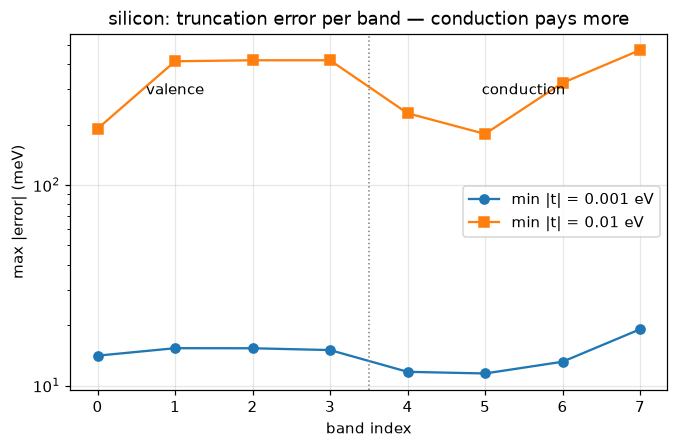

cut 0.001: mean error valence 3.84 meV, conduction 5.03 meV
cut 0.01: mean error valence 107.58 meV, conduction 108.40 meV
[PASS] I.6: conduction bands interpolate worse than valence bands


True

In [7]:
silicon = W90("data/w90_silicon", "si")
fermi_ev = 6.2285135
w90_kpt, w90_evals = silicon.bands_w90()[:2]

errs = {}
for cut in (1e-3, 1e-2):
    m = silicon.model(zero_energy=fermi_ev, min_hopping_norm=cut)
    e = np.abs(m.solve_ham(w90_kpt) - (w90_evals - fermi_ev))
    errs[cut] = e

fig, ax = plt.subplots()
for cut, marker in ((1e-3, "o"), (1e-2, "s")):
    ax.semilogy(np.arange(8), errs[cut].max(axis=0) * 1000, marker + "-",
                label=f"min |t| = {cut} eV")
ax.axvline(3.5, color="gray", ls=":", lw=1)
ax.text(1.0, ax.get_ylim()[1] * 0.5, "valence", ha="center")
ax.text(5.5, ax.get_ylim()[1] * 0.5, "conduction", ha="center")
ax.set_xlabel("band index"); ax.set_ylabel("max |error| (meV)")
ax.legend(); ax.set_title("silicon: truncation error per band — conduction pays more")
plt.show()
caption("Truncation error of the silicon Wannier model, resolved band by band "
        "(valence 0–3, conduction 4–7) for two hopping cutoffs. The conduction "
        "bands, built from less-localized antibonding/disentangled Wannier "
        "functions, lose accuracy faster when distant hoppings are discarded — "
        "localization quality translates directly into interpolation quality.")

for cut in (1e-3, 1e-2):
    ev_err = errs[cut]
    val, cond = ev_err[:, :4].mean(), ev_err[:, 4:].mean()
    print(f"cut {cut}: mean error valence {1000*val:.2f} meV, conduction {1000*cond:.2f} meV")
check("I.6: conduction bands interpolate worse than valence bands",
      errs[1e-3][:, 4:].mean() > errs[1e-3][:, :4].mean()
      and errs[1e-2][:, 4:].mean() > errs[1e-2][:, :4].mean())

## II.1 — Competing masses in the Haldane model

At the two valleys the gap is $|\Delta \mp 3\sqrt3\, t_2 \sin\phi|$: the Semenoff mass $\Delta$ has
the *same* sign at $K$ and $K'$, the Haldane mass alternates. Crossing the phase boundary closes
the gap at exactly one valley — the other stays open, which is why the Chern number changes by
$\pm 1$ and not $\pm 2$.

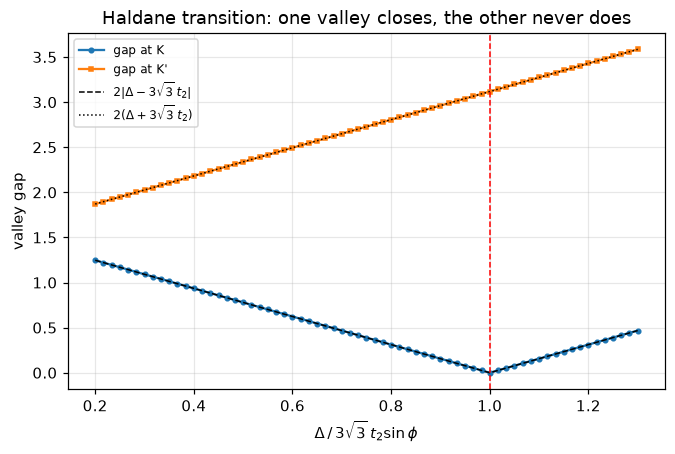

[PASS] II.1: valley gaps match 2|Δ ∓ 3√3 t₂ sinφ|
[PASS] II.1: at the transition only one valley is gapless


True

In [8]:
t2v, phiv = 0.15, np.pi / 2
crit = 3 * np.sqrt(3) * t2v * np.sin(phiv)
d_scan = np.linspace(0.2, 1.3, 67) * crit   # 67 points puts Delta = crit on the grid
K_pt, Kp_pt = np.array([[2/3, 1/3]]), np.array([[1/3, 2/3]])
gap_K = np.array([np.diff(np.atleast_2d(haldane(delta=d, t1=-1.0, t2=t2v, phi=phiv)
                          .solve_ham(K_pt)))[0, 0] for d in d_scan])
gap_Kp = np.array([np.diff(np.atleast_2d(haldane(delta=d, t1=-1.0, t2=t2v, phi=phiv)
                           .solve_ham(Kp_pt)))[0, 0] for d in d_scan])

# which valley carries which mass depends on the factory's sign conventions:
# compare the SET {gap_K, gap_K'} against the analytic set {|Δ-m_H|, Δ+m_H}
gap_soft = np.minimum(gap_K, gap_Kp)
gap_hard = np.maximum(gap_K, gap_Kp)

fig, ax = plt.subplots()
ax.plot(d_scan / crit, gap_K, "o-", ms=3, label="gap at K")
ax.plot(d_scan / crit, gap_Kp, "s-", ms=3, label="gap at K'")
ax.plot(d_scan / crit, 2 * np.abs(d_scan - crit), "k--", lw=1,
        label=r"$2|\Delta - 3\sqrt{3}\, t_2|$")
ax.plot(d_scan / crit, 2 * (d_scan + crit), "k:", lw=1,
        label=r"$2(\Delta + 3\sqrt{3}\, t_2)$")
ax.axvline(1.0, color="r", ls="--", lw=1)
ax.set_xlabel(r"$\Delta \,/\, 3\sqrt{3}\, t_2\sin\phi$"); ax.set_ylabel("valley gap")
ax.legend(fontsize=8)
ax.set_title("Haldane transition: one valley closes, the other never does")
plt.show()
caption("Valley-resolved gaps across the Haldane transition: one valley's gap "
        "closes linearly at Δ = 3√3 t₂ sinφ while the other's keeps growing — the "
        "numerics landing exactly on 2|Δ ∓ m_H| (guides). A Chern number can only "
        "change by the chirality of the single Dirac cone that closes, which is "
        "why the transition steps C by 1 and not by 2.")

# onsite energies are ±Δ, so the K-point splitting is 2|m|: gaps = 2|Δ ∓ m_H|
check("II.1: valley gaps match 2|Δ ∓ 3√3 t₂ sinφ|",
      np.allclose(gap_soft, 2 * np.abs(d_scan - crit), atol=1e-10)
      and np.allclose(gap_hard, 2 * (d_scan + crit), atol=1e-10))
check("II.1: at the transition only one valley is gapless",
      np.min(gap_soft) < 1e-10 and np.min(gap_hard) > 2 * crit)

## II.2 — Kane–Mele phase map

Automating the Wannier-flow parity of §15 over the $(\Delta, \lambda_{SO})$ plane and comparing
with the analytic boundary $\Delta = 3\sqrt3\,\lambda_{SO}$ (exact at Rashba = 0; we keep a small
Rashba to make the test non-trivial and stay clear of the boundary itself).

36-point phase map in 0.7 s


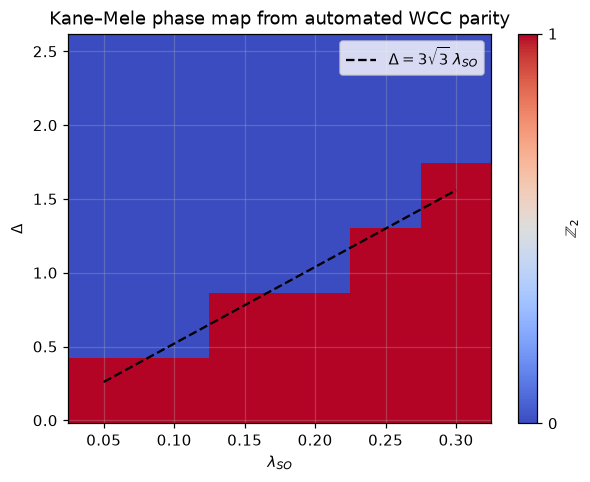

[PASS] II.2: WCC parity reproduces the analytic phase boundary — 36/36 grid points agree outright


True

In [9]:
def z2_from_wcc(w, ref):
    def arc(a, b):
        return (b - a + 0.5) % 1.0 - 0.5
    crossings = 0
    for r in range(len(w) - 1):
        w1, w2 = w[r], w[r + 1]
        d_keep = [arc(w1[0], w2[0]), arc(w1[1], w2[1])]
        d_swap = [arc(w1[0], w2[1]), arc(w1[1], w2[0])]
        d = d_keep if sum(map(abs, d_keep)) <= sum(map(abs, d_swap)) else d_swap
        for a, dd in zip(w1, d):
            if dd > 0 and (ref - a) % 1.0 < dd:
                crossings += 1
            elif dd < 0 and (a - ref) % 1.0 < -dd:
                crossings += 1
    return crossings % 2

def km_z2(delta, soc, rashba=0.05):
    m = kane_mele(delta=delta, t=1.0, soc=soc, rashba=rashba)
    mesh = Mesh(["k", "k"])
    mesh.build_grid((41, 31), k_endpoints=[True, True])
    wfa = WFArray(m.lattice, mesh, spinful=True)
    wfa.solve_model(m)
    wcc = np.asarray(wfa.berry_phase(axis_idx=0, state_idx=[0, 1],
                                     berry_evals=True, contin=False)) / (2 * np.pi) % 1.0
    ky = mesh.get_axis_range(1, 1)
    return z2_from_wcc(wcc[ky <= 0.5 + 1e-9], 0.31)

socs = np.linspace(0.05, 0.30, 6)
dels = np.linspace(0.2, 2.4, 6)
zmap = np.zeros((len(dels), len(socs)), int)
t0 = time.time()
for i, dv in enumerate(dels):
    for j, sv in enumerate(socs):
        zmap[i, j] = km_z2(dv, sv)
print(f"36-point phase map in {time.time()-t0:.1f} s")

fig, ax = plt.subplots(figsize=(6.2, 4.6))
im = ax.pcolormesh(socs, dels, zmap, cmap="coolwarm", shading="auto", vmin=0, vmax=1)
soc_line = np.linspace(socs[0], socs[-1], 100)
ax.plot(soc_line, 3 * np.sqrt(3) * soc_line, "k--", lw=1.5,
        label=r"$\Delta = 3\sqrt{3}\,\lambda_{SO}$")
fig.colorbar(im, label=r"$\mathbb{Z}_2$", ticks=[0, 1])
ax.set_xlabel(r"$\lambda_{SO}$"); ax.set_ylabel(r"$\Delta$")
ax.legend(); ax.set_title("Kane–Mele phase map from automated WCC parity")
plt.show()
caption("The Kane–Mele phase diagram mapped by running the Wannier-flow parity "
        "of §15 at every grid point: Z₂ = 1 (red) below the analytic boundary "
        "Δ = 3√3 λ_SO (dashed), 0 above, with only near-boundary points shifted "
        "slightly by the small Rashba term. An invariant that can be evaluated "
        "blindly on a grid is an invariant that can map phase diagrams.")

analytic = (dels[:, None] < 3 * np.sqrt(3) * socs[None, :]).astype(int)
agree = (zmap == analytic)
# tolerate points within 10% of the boundary (small Rashba shifts it slightly)
dist = np.abs(dels[:, None] - 3 * np.sqrt(3) * socs[None, :]) / (3 * np.sqrt(3) * socs[None, :])
agree_far = agree | (dist < 0.10)
check("II.2: WCC parity reproduces the analytic phase boundary",
      np.all(agree_far), f"{agree.sum()}/{agree.size} grid points agree outright")

## II.3 — From quantum spin Hall to quantum anomalous Hall

An exchange field $M_z s_z$ splits the two time-reversed BHZ blocks: one block's mass is pushed
through zero while the other's grows. In the window where exactly one block is inverted the total
Chern number is $\pm 1$ — a quantum anomalous Hall phase engineered from a QSH parent, the
mechanism behind the Cr-doped (Bi,Sb)₂Te₃ experiments (2013).

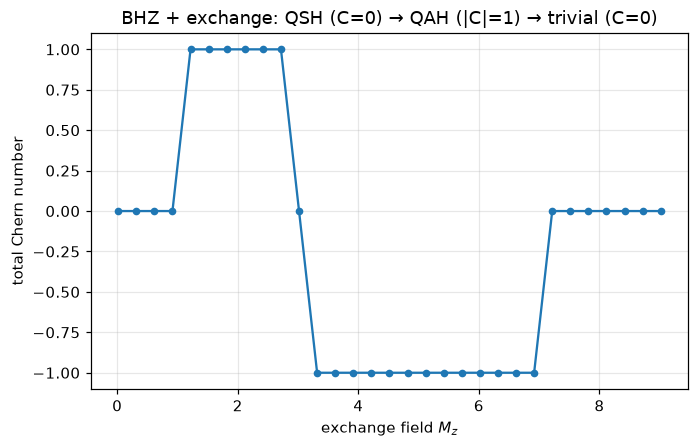

[PASS] II.3: a |C| = 1 QAH window opens between two C = 0 phases — C sequence: [ 0.  1.  1. -1. -1. -1. -0. -0.]


True

In [10]:
def bhz_exchange(M, Mz, A=1.0, B=1.0):
    s0 = np.eye(2); sz = np.diag([1.0, -1.0])
    lat = Lattice(lat_vecs=[[1, 0], [0, 1]], orb_vecs=[[0, 0], [0, 0]],
                  periodic_dirs=[0, 1])
    m = TBModel(lat, spinful=True)
    # exchange enters ORBITAL-ANTISYMMETRICALLY (different g-factors of the E1/H1
    # bands): only then does it shift the block masses M -> M ± Mz rather than
    # rigidly shifting both blocks' energies
    m.set_onsite([[(M - 4 * B), 0, 0, Mz], [-(M - 4 * B), 0, 0, -Mz]])
    for R in ([1, 0], [0, 1]):
        m.set_hop(B * s0, 0, 0, R)
        m.set_hop(-B * s0, 1, 1, R)
    m.set_hop(A / (2j) * sz, 0, 1, [1, 0])
    m.set_hop(-A / (2j) * sz, 0, 1, [-1, 0], allow_conjugate_pair=True)
    m.set_hop(-A / 2 * s0, 0, 1, [0, 1])
    m.set_hop(A / 2 * s0, 0, 1, [0, -1], allow_conjugate_pair=True)
    return m

Mz_scan = np.linspace(0.0, 9.0, 31) + 0.017          # offset avoids exact closings
C_scan = []
for Mz in Mz_scan:
    try:
        C_scan.append(float(bhz_exchange(1.0, Mz).chern_number(
            plane=(0, 1), nks=(25, 25), occ_idxs=[0, 1])))
    except ZeroDivisionError:
        C_scan.append(np.nan)
C_scan = np.array(C_scan)

fig, ax = plt.subplots()
ax.plot(Mz_scan, np.round(C_scan), "o-", ms=4)
ax.set_xlabel(r"exchange field $M_z$"); ax.set_ylabel("total Chern number")
ax.set_title("BHZ + exchange: QSH (C=0) → QAH (|C|=1) → trivial (C=0)")
plt.show()
caption("Total Chern number of the BHZ model versus exchange field: the QSH "
        "phase (C = 0, but Z₂ = 1) gives way to a quantum anomalous Hall window "
        "with |C| = 1 once the exchange field un-inverts ONE spin block "
        "(Mz > M), and to a fully trivial phase when it un-inverts the other "
        "(Mz > 8B − M). This QSH-parent route is precisely how the QAH effect was "
        "first realized experimentally in magnetically doped (Bi,Sb)₂Te₃.")

C_r = np.round(C_scan[~np.isnan(C_scan)])
check("II.3: a |C| = 1 QAH window opens between two C = 0 phases",
      np.any(np.abs(C_r) == 1) and C_r[0] == 0 and C_r[-1] == 0,
      f"C sequence: {C_r[::4]}")

## II.4 — The corner-charge pump

Drive BBH around $\gamma(\lambda) = 1 + 0.8\cos 2\pi\lambda$ with a chiral-symmetry-breaking
onsite $\delta(\lambda) = 0.8\sin 2\pi\lambda$ staggered between the two sublattice pairs. At
$\lambda = 1/2$ the system passes through the quadrupole phase with the onsite term off — corner
modes at zero — while at $\lambda = 0$ it is trivial. The four corner levels must traverse the gap:
a quantized *quadrupole* pump, one dimension of hierarchy above Rice–Mele.

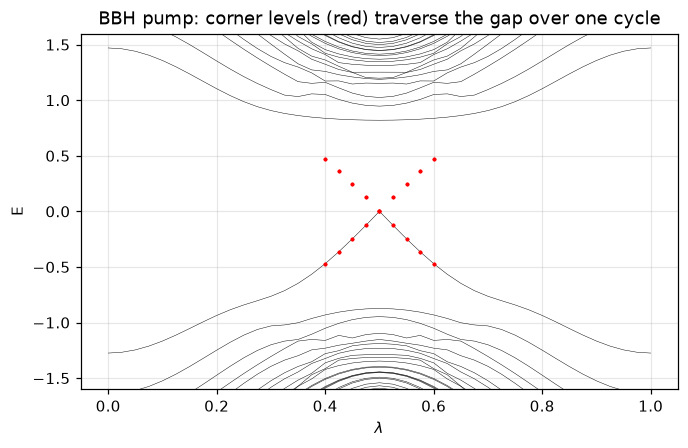

[PASS] II.4: four corner zero modes at λ = 1/2 — |E|min = 3.5e-06, count = 4
[PASS] II.4: no mid-gap states at λ = 0 (trivial point) — |E|min(λ=0) = 1.275
[PASS] II.4: spectrum returns after a full cycle


True

In [11]:
def bbh_pump(lmbda, lam_inter=1.0):
    g = 1.0 + 0.8 * np.cos(2 * np.pi * lmbda)
    d = 0.8 * np.sin(2 * np.pi * lmbda)
    lat = Lattice(lat_vecs=[[1, 0], [0, 1]],
                  orb_vecs=[[0, 0], [0.5, 0], [0, 0.5], [0.5, 0.5]],
                  periodic_dirs=[0, 1])
    m = TBModel(lat)
    m.set_onsite([d, -d, -d, d])
    m.set_hop(g, 0, 1, [0, 0]); m.set_hop(g, 2, 3, [0, 0])
    m.set_hop(g, 0, 2, [0, 0]); m.set_hop(-g, 1, 3, [0, 0])
    m.set_hop(lam_inter, 1, 0, [1, 0]); m.set_hop(lam_inter, 3, 2, [1, 0])
    m.set_hop(lam_inter, 2, 0, [0, 1]); m.set_hop(-lam_inter, 3, 1, [0, 1])
    return m

lam_grid = np.linspace(0, 1, 41)
spec = np.array([np.sort(bbh_pump(l).make_finite(periodic_dirs=[0, 1],
                 num_cells=[8, 8]).solve_ham()) for l in lam_grid])

fig, ax = plt.subplots()
ax.plot(lam_grid, spec[:, ::6], "k-", lw=0.3)
mid = np.abs(spec) < 0.55
for i, l in enumerate(lam_grid):
    ax.plot([l] * mid[i].sum(), spec[i][mid[i]], "r.", ms=3)
ax.set_xlabel(r"$\lambda$"); ax.set_ylabel("E")
ax.set_ylim(-1.6, 1.6)
ax.set_title("BBH pump: corner levels (red) traverse the gap over one cycle")
plt.show()
caption("The quadrupole pump: finite-sample BBH spectrum along the drive cycle, "
        "with in-gap states highlighted. The four corner levels detach from the "
        "bands, meet at zero at the chiral-symmetric point λ = ½ (where the model "
        "is in its quadrupole phase), and traverse to the other band — corner "
        "charge is pumped by e/2 per corner per cycle, the higher-order echo of "
        "the Rice–Mele pump one dimension of boundary down.")

E0_half = np.abs(spec[len(lam_grid) // 2]).min()
n_zero_half = int((np.abs(spec[len(lam_grid) // 2]) < 1e-3).sum())
check("II.4: four corner zero modes at λ = 1/2", n_zero_half == 4,
      f"|E|min = {E0_half:.1e}, count = {n_zero_half}")
check("II.4: no mid-gap states at λ = 0 (trivial point)",
      np.abs(spec[0]).min() > 0.3, f"|E|min(λ=0) = {np.abs(spec[0]).min():.3f}")
check("II.4: spectrum returns after a full cycle",
      np.allclose(spec[0], spec[-1], atol=1e-10))

## II.5 — A Zak phase for the Kitaev chain

The lower BdG band's Berry phase jumps by $\pi$ at $\mu = 2t$ — numerically crisp, but its
*meaning* needs care. The BdG "valence band" is not a physical filling: the redundancy
$\mathcal{C}H\mathcal{C}^{-1} = -H$ means we diagonalize each degree of freedom twice, and the Zak
phase works as a class-D indicator here only because particle-hole symmetry quantizes it — a fact
we asserted, and PythTB cannot certify (§28). The honest invariant is the Pfaffian sign
$\mathrm{sgn}[\mathrm{Pf}\,iH(0)\cdot\mathrm{Pf}\,iH(\pi)]$; the Zak phase is its shadow.

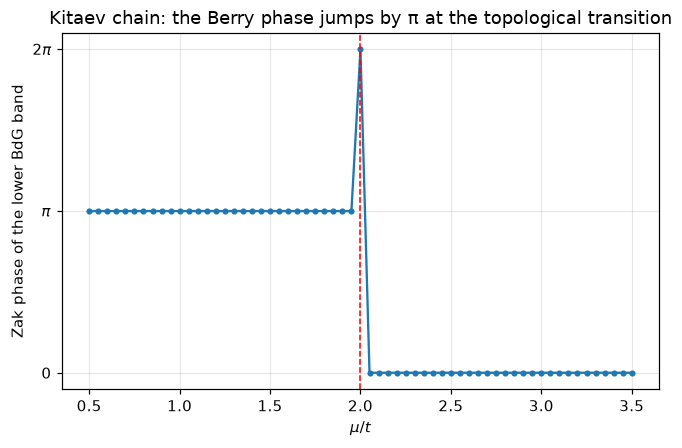

[PASS] II.5: Zak phase is flat on both sides and jumps by π at μ = 2t — |Δφ| = 3.14159


True

In [12]:
def kitaev(mu, t=1.0, Delta=0.6):
    lat = Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0], [0.0]], periodic_dirs=[0])
    m = TBModel(lat)
    m.set_onsite([-mu, +mu])
    m.set_hop(-t, 0, 0, [1]); m.set_hop(+t, 1, 1, [1])
    m.set_hop(-Delta, 0, 1, [1])
    m.set_hop(+Delta, 0, 1, [-1], allow_conjugate_pair=True)
    return m

mu_scan = np.linspace(0.5, 3.5, 61)
zak = []
for mu in mu_scan:
    m = kitaev(mu)
    mesh = Mesh(["k"]); mesh.build_grid([81], k_endpoints=True)
    wfa = WFArray(m.lattice, mesh); wfa.solve_model(m)
    zak.append(float(np.squeeze(wfa.berry_phase(axis_idx=0, state_idx=[0]))) % (2 * np.pi))
zak = np.array(zak)

fig, ax = plt.subplots()
ax.plot(mu_scan, zak, "o-", ms=3)
ax.axvline(2.0, color="r", ls="--", lw=1)
ax.set_yticks([0, np.pi, 2 * np.pi], ["0", r"$\pi$", r"$2\pi$"])
ax.set_xlabel(r"$\mu / t$"); ax.set_ylabel("Zak phase of the lower BdG band")
ax.set_title("Kitaev chain: the Berry phase jumps by π at the topological transition")
plt.show()
caption("Zak phase of the lower BdG band versus chemical potential: pinned to π "
        "throughout the topological phase, to 0 in the trivial one, jumping "
        "discontinuously at μ = 2t where the bulk gap closes. The quantization is "
        "enforced by particle-hole symmetry — a fact WE must supply, since PythTB "
        "computes the number without knowing the symmetry class it lives in.")

# circular statistics: phases live on a circle, so flatness is |<e^{iφ}>| ≈ 1
z_topo = np.exp(1j * zak[mu_scan < 1.9])
z_triv = np.exp(1j * zak[mu_scan > 2.1])
dphi = np.abs(np.angle(z_topo.mean() / z_triv.mean()))
check("II.5: Zak phase is flat on both sides and jumps by π at μ = 2t",
      np.abs(z_topo.mean()) > 0.9999 and np.abs(z_triv.mean()) > 0.9999
      and abs(dphi - np.pi) < 1e-2,
      f"|Δφ| = {dphi:.5f}")

## II.6 — Annihilating Weyl nodes

Adding $b\,\sigma_z$ shifts the mass: nodes sit where $\cos K_z = \cos K_0 + b$ on the $k_z$
axis. For $b > 0$ they merge at $\Gamma$ at $b_c^+ = 1 - \cos K_0$ and leave a plain trivial
insulator. The $b < 0$ channel is where the exercise earns its keep: the continuum picture
("nodes annihilate at the boundary, leaving a Chern stack") is **wrong on the lattice**. Solve
the mass conditions at *all* high-symmetry columns: the original nodes at $\Gamma$-column die at
$b_c^- = -1 - \cos K_0$, but at exactly the same coupling the mass at the $X$ columns
($\cos K_z = 2 + \cos K_0 + b$) starts changing sign — a **new pair of Weyl-node families is born
at $(\pi, 0, k_z)$ and $(0, \pi, k_z)$** the instant the old ones die. Past $b_c^-$ the slice
Chern number is $+1$ between the new nodes and $-1$ outside them. The lesson generalizes:
fermion-doubling partners lurk at every zone corner of a lattice regularization, and no package —
PythTB or Kwant — will warn you when your continuum reasoning walks past one.

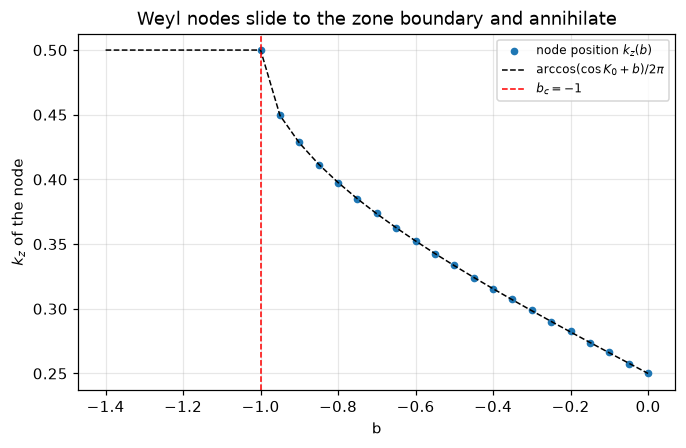

[PASS] II.6: nodes exist up to b_c⁻ and the gap opens beyond — b_c⁻ = -1.00
b = +1.3 (Γ annihilation):        C(kz) = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[PASS] II.6: Γ annihilation leaves a trivial insulator (C = 0 at every kz)
predicted new node position on the X columns: kz = ±0.1266
b = -1.3: C(|kz| < 0.127) = [0.999 0.997],  C(|kz| > 0.127) = [-1. -1.]
[PASS] II.6: past b_c⁻ NEW nodes at the X columns flip the slice Chern to +1 — the continuum 'clean annihilation' picture fails on the lattice
[PASS] II.6: gap closes at the predicted new node (0.5, 0, kz_X) — |E| = 1.7e-16


True

In [13]:
K0 = np.pi / 2
sx_ = np.array([[0, 1], [1, 0]], dtype=complex)
sy_ = np.array([[0, -1j], [1j, 0]])
sz_ = np.diag([1.0, -1.0]).astype(complex)

def weyl_b(b):
    lat = Lattice(lat_vecs=np.eye(3), orb_vecs=[[0, 0, 0]], periodic_dirs=[0, 1, 2])
    m = TBModel(lat, spinful=True)
    m.set_onsite([[0, 0, 0, 2 + np.cos(K0) + b]])
    m.set_hop(-0.5j * sx_ - 0.5 * sz_, 0, 0, [1, 0, 0])
    m.set_hop(-0.5j * sy_ - 0.5 * sz_, 0, 0, [0, 1, 0])
    m.set_hop(-0.5 * sz_, 0, 0, [0, 0, 1])
    return m

b_c = -1 - np.cos(K0)
kz_line = np.linspace(0, 0.5, 401)
k_line = np.stack([np.zeros_like(kz_line), np.zeros_like(kz_line), kz_line], axis=1)

b_scan = np.linspace(-1.4, 0.0, 29)
node_pos, min_gap = [], []
for b in b_scan:
    gap = np.diff(weyl_b(b).solve_ham(k_line), axis=1).ravel()
    min_gap.append(gap.min())
    # on a discrete kz grid a true node shows up as a near-closing at the grid scale
    node_pos.append(kz_line[np.argmin(gap)] if gap.min() < 0.02 else np.nan)

fig, ax = plt.subplots()
ax.plot(b_scan, node_pos, "o", ms=4, label=r"node position $k_z(b)$")
ax.plot(b_scan, np.arccos(np.clip(np.cos(K0) + b_scan, -1, 1)) / (2 * np.pi),
        "k--", lw=1, label=r"$\arccos(\cos K_0 + b)/2\pi$")
ax.axvline(b_c, color="r", ls="--", lw=1, label=f"$b_c = {b_c:.0f}$")
ax.set_xlabel("b"); ax.set_ylabel(r"$k_z$ of the node")
ax.legend(fontsize=8); ax.set_title("Weyl nodes slide to the zone boundary and annihilate")
plt.show()
caption("Weyl node position along kz as the σz field b is tuned: the numerically "
        "detected gap minima (circles) follow the analytic arccos law (dashed) "
        "until the nodes meet at the zone boundary at b = −1. What happens beyond "
        "is the exercise's real lesson — see the slice Chern numbers below.")

gap_after = np.array(min_gap)[b_scan < b_c - 0.05]
check("II.6: nodes exist up to b_c⁻ and the gap opens beyond",
      np.all(np.array(min_gap)[b_scan > b_c + 0.05] < 0.02)
      and np.all(gap_after > 1e-3),
      f"b_c⁻ = {b_c:.2f}")

# slice Chern numbers on both sides of the two annihilation channels
def weyl_slice_b(b):
    lat = Lattice(lat_vecs=np.eye(2), orb_vecs=[[0, 0]], periodic_dirs=[0, 1])
    m = TBModel(lat, spinful=True)
    m.set_onsite(lambda kz: [0, 0, 0, 2 + np.cos(K0) + b - np.cos(2 * np.pi * kz)],
                 ind_i=0)
    m.set_hop(-0.5j * sx_ - 0.5 * sz_, 0, 0, [1, 0])
    m.set_hop(-0.5j * sy_ - 0.5 * sz_, 0, 0, [0, 1])
    return m

# b = +1.3: clean Γ annihilation, trivial insulator
kz_probe = (np.arange(10) + 0.5) / 10 - 0.5
C_triv = [float(weyl_slice_b(+1.3).chern_number(plane=(0, 1), nks=(25, 25),
          occ_idxs=[0], kz=kz)) for kz in kz_probe]
print("b = +1.3 (Γ annihilation):        C(kz) =", np.round(C_triv, 2))
check("II.6: Γ annihilation leaves a trivial insulator (C = 0 at every kz)",
      np.allclose(np.round(C_triv), 0))

# b = -1.3: the lattice surprise — new X-column nodes at cos(Kz) = 2 + cos(K0) + b
kz_X = np.arccos(2 + np.cos(K0) - 1.3) / (2 * np.pi)
print(f"predicted new node position on the X columns: kz = ±{kz_X:.4f}")
sl_m = weyl_slice_b(-1.3)
C_in = [float(sl_m.chern_number(plane=(0, 1), nks=(31, 31), occ_idxs=[0], kz=kz))
        for kz in (0.02, 0.06)]                       # inside the new node pair
C_out = [float(sl_m.chern_number(plane=(0, 1), nks=(31, 31), occ_idxs=[0], kz=kz))
         for kz in (0.30, 0.45)]                      # outside it
print(f"b = -1.3: C(|kz| < {kz_X:.3f}) = {np.round(C_in, 3)},  "
      f"C(|kz| > {kz_X:.3f}) = {np.round(C_out, 3)}")
check("II.6: past b_c⁻ NEW nodes at the X columns flip the slice Chern to +1",
      np.allclose(np.round(C_in), 1) and np.allclose(np.round(C_out), -1),
      "the continuum 'clean annihilation' picture fails on the lattice")
# gap must close at the predicted X-column node
gap_X = np.abs(weyl_b(-1.3).solve_ham(np.array([[0.5, 0.0, kz_X]]))).min()
check("II.6: gap closes at the predicted new node (0.5, 0, kz_X)",
      gap_X < 1e-8, f"|E| = {gap_X:.1e}")

## III.1 — Coloring the butterfly: gap Chern numbers and the Diophantine equation

Each magnetic subband at flux $p/q$ carries a Chern number, and the $r$-th gap satisfies the
TKNN/Streda Diophantine equation $r = q\,s_r + p\,C_r$ with integers $(s_r, C_r)$, $C_r$ the Hall
conductance of the gap. We compute subband Cherns with `WFArray.chern_number` on the magnetic
supercell and verify the equation for every gap at several fluxes.

In [14]:
from math import gcd

def hofstadter_model(p, q, t=1.0):
    lat = Lattice(lat_vecs=[[q, 0], [0, 1]],
                  orb_vecs=[[i / q, 0] for i in range(q)], periodic_dirs=[0, 1])
    m = TBModel(lat)
    for i in range(q):
        m.set_hop(-t, i, (i + 1) % q, [1 if i == q - 1 else 0, 0])
        m.set_hop(-t * np.exp(2j * np.pi * p / q * i), i, i, [0, 1])
    return m

all_ok = True
for q in (3, 4, 5):
    for p in range(1, q):
        if gcd(p, q) != 1:
            continue
        hm = hofstadter_model(p, q)
        mesh = Mesh(["k", "k"])
        mesh.build_grid((31, 31), k_endpoints=[True, True])
        wfa = WFArray(hm.lattice, mesh)
        wfa.solve_model(hm)
        # the Diophantine equation applies to OPEN gaps, and a gap Chern number
        # must be computed as the JOINT Chern of all bands below it — for even q
        # the two central subbands touch at E = 0, so their individual Chern
        # numbers are meaningless while their joint contribution is fine
        ev_g = hm.solve_ham(hm.k_uniform_mesh([25, 25]))
        gap_cherns = {}
        for r in range(1, q):
            if ev_g[:, r].min() - ev_g[:, r - 1].max() < 0.05:
                continue                                   # closed: not a gap
            Cr_f = float(wfa.chern_number(plane=(0, 1), state_idx=list(range(r))))
            Cr = int(round(Cr_f))
            gap_cherns[r] = Cr
            all_ok &= abs(Cr_f - Cr) < 1e-4 and (r - p * Cr) % q == 0
        print(f"p/q = {p}/{q}:  open-gap Cherns {gap_cherns}")
check("III.1: Diophantine r = q s + p C holds for every OPEN gap at q = 3, 4, 5", all_ok)

p/q = 1/3:  open-gap Cherns {1: 1, 2: -1}
p/q = 2/3:  open-gap Cherns {1: -1, 2: 1}
p/q = 1/4:  open-gap Cherns {1: 1, 3: -1}


p/q = 3/4:  open-gap Cherns {1: -1, 3: 1}
p/q = 1/5:  open-gap Cherns {1: 1, 2: 2, 3: -2, 4: -1}


p/q = 2/5:  open-gap Cherns {1: -2, 2: 1, 3: -1, 4: 2}
p/q = 3/5:  open-gap Cherns {1: 2, 2: -1, 3: 1, 4: -2}


p/q = 4/5:  open-gap Cherns {1: -1, 2: -2, 3: 2, 4: 1}
[PASS] III.1: Diophantine r = q s + p C holds for every OPEN gap at q = 3, 4, 5


True

## III.2 — Other lattices, and relativistic Landau levels

**Triangular lattice butterfly.** Adding the $(1,1)$ diagonal bond to the square-lattice magnetic
supercell (Landau-gauge phase evaluated at the bond midpoint $x = i + \tfrac12$) puts flux $\phi/2$
through each triangle. The butterfly loses the $E \to -E$ symmetry — the triangular lattice is not
bipartite.

**$\sqrt{B}$ Landau levels.** The square lattice at $\phi = \tfrac12$ hosts Dirac cones; detuning
to $\phi = \tfrac12 + \delta$ puts the *relativistic* Landau spectrum $E_n \propto \sqrt{n\delta}$
on top of them — the same physics as graphene in a field, extracted here from the Hofstadter code
with no new machinery: the level ratios must approach $\sqrt2$ and $\sqrt3$.

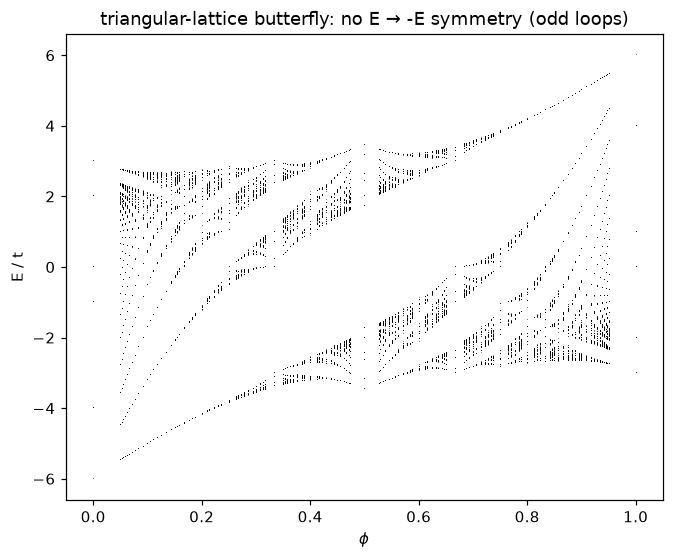

[PASS] III.2a: triangular spectrum at fixed flux is NOT particle-hole symmetric — E range [-3.86, 2.83]


True

In [15]:
def triangular_hof(p, q, t=1.0):
    m = hofstadter_model(p, q, t)
    for i in range(q):
        # (1,1) diagonal bond; Landau-gauge phase at midpoint x = i + 1/2
        m.set_hop(-t * np.exp(2j * np.pi * p / q * (i + 0.5)),
                  i, (i + 1) % q, [1 if i == q - 1 else 0, 1])
    return m

phi_pts, E_pts = [], []
for q in range(1, 21):
    for p in range(q + 1):
        if gcd(p, q) != 1 and not (p == 0 and q == 1):
            continue
        hm = triangular_hof(p, q)
        ev = hm.solve_ham(hm.k_uniform_mesh([6, 6], include_endpoints=False))
        phi_pts.append(np.full(ev.size, p / q)); E_pts.append(ev.ravel())

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(np.concatenate(phi_pts), np.concatenate(E_pts), ",", color="k", alpha=0.5)
ax.set_xlabel(r"$\phi$"); ax.set_ylabel("E / t"); ax.grid(False)
ax.set_title("triangular-lattice butterfly: no E → -E symmetry (odd loops)")
plt.show()
caption("The Hofstadter butterfly of the triangular lattice: recognizably a "
        "butterfly, but sheared — the spectrum is not symmetric under E → −E at "
        "fixed flux, because triangular plaquettes support odd-length hopping "
        "loops that a bipartite lattice forbids. Lattice geometry leaves its "
        "fingerprint even on this Cantor-set spectrum.")

# PH asymmetry must be tested at FIXED flux (the union over all phi happens to
# be symmetric under phi -> phi + 1/2 combined with E -> -E)
hm_q = triangular_hof(1, 4)
ev_q = np.sort(hm_q.solve_ham(hm_q.k_uniform_mesh([20, 20])).ravel())
check("III.2a: triangular spectrum at fixed flux is NOT particle-hole symmetric",
      not np.allclose(ev_q, -ev_q[::-1], atol=1e-6),
      f"E range [{ev_q.min():.2f}, {ev_q.max():.2f}]")

first Landau levels |E_n|: [0.     0.6979 0.9713 1.1705 1.3295]


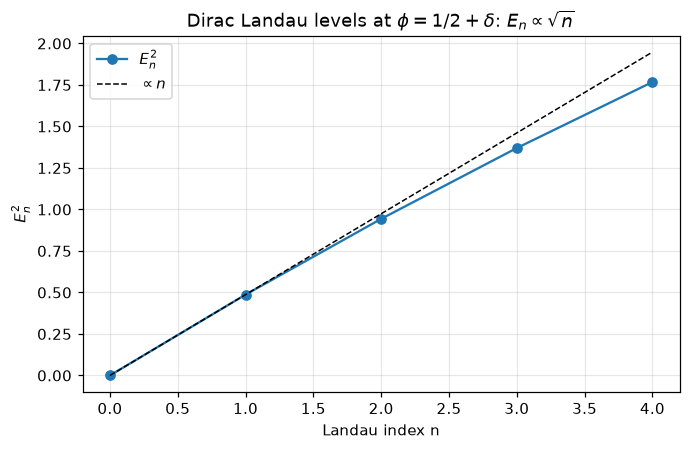

[PASS] III.2b: E_0 ≈ 0 (the anomalous zero mode of Dirac fermions) — E_0/E_1 = 0.000
[PASS] III.2b: level ratios follow sqrt(n) — E2/E1 = 1.392 (√2 = 1.414), E3/E1 = 1.677 (√3 = 1.732)


True

In [16]:
# relativistic Landau levels at phi = 1/2 + 1/q0
q0 = 100
hm = hofstadter_model(q0 // 2 + 1, q0)            # phi = 51/100
ev0 = np.sort(np.abs(np.atleast_2d(hm.solve_ham(np.array([[0.0, 0.0]])))[0]))

# cluster the |E| values into Landau levels (each appears twice: two Dirac cones)
levels, used = [], np.zeros(len(ev0), bool)
for e in ev0:
    if not levels or e - levels[-1][-1] > 0.05:
        levels.append([e])
    else:
        levels[-1].append(e)
E_LL = np.array([np.mean(l) for l in levels[:5]])
print("first Landau levels |E_n|:", np.round(E_LL, 4))

r2, r3 = E_LL[2] / E_LL[1], E_LL[3] / E_LL[1]
fig, ax = plt.subplots()
n_idx = np.arange(len(E_LL))
ax.plot(n_idx, E_LL ** 2, "o-", label=r"$E_n^2$")
ax.plot(n_idx, E_LL[1] ** 2 * n_idx, "k--", lw=1, label=r"$\propto n$")
ax.set_xlabel("Landau index n"); ax.set_ylabel(r"$E_n^2$")
ax.legend(); ax.set_title(r"Dirac Landau levels at $\phi = 1/2 + \delta$: $E_n \propto \sqrt{n}$")
plt.show()
caption("Relativistic Landau quantization extracted from the Hofstadter "
        "spectrum: at flux ½ + δ the π-flux Dirac cones feel an effective field δ, "
        "and the level energies squared fall on a straight line through the "
        "origin — E_n ∝ √n, with the n = 0 level pinned at zero. The same "
        "√B fan measured by STM on graphene, obtained here without writing a "
        "single new model.")

check("III.2b: E_0 ≈ 0 (the anomalous zero mode of Dirac fermions)",
      E_LL[0] < 0.1 * E_LL[1], f"E_0/E_1 = {E_LL[0]/E_LL[1]:.3f}")
check("III.2b: level ratios follow sqrt(n)",
      abs(r2 - np.sqrt(2)) < 0.08 * np.sqrt(2) and abs(r3 - np.sqrt(3)) < 0.1 * np.sqrt(3),
      f"E2/E1 = {r2:.3f} (√2 = 1.414), E3/E1 = {r3:.3f} (√3 = 1.732)")

## III.3 — The 1D localization length

In 1D every state localizes; at weak disorder second-order perturbation theory gives the band-center
localization length $\xi \approx 105.2\,t^2/W^2$ (in sites; the naive Thouless value $96\,t^2/W^2$
is corrected by the well-known band-center anomaly — another statement the numerics gets to
adjudicate). We estimate $\xi$ from the exponential envelope of band-center eigenstates,
averaging log-densities over several states and realizations.

In [17]:
def xi_estimate(W, L=1200, n_states=6, n_real=3):
    lat = Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0]], periodic_dirs=[0])
    ch = TBModel(lat); ch.set_hop(-1.0, 0, 0, [1])
    base = ch.cut_piece(L, 0)
    slopes = []
    for r in range(n_real):
        dis = base.copy()
        rng_r = np.random.default_rng(100 + r)
        dis.set_onsite(list(rng_r.uniform(-W / 2, W / 2, L)), mode="reset")
        ev, vec = dis.solve_ham(return_eigvecs=True)
        for idx in np.argsort(np.abs(ev))[:n_states]:
            dens = np.abs(vec[idx]) ** 2
            i0 = int(np.argmax(dens))
            # fit the decaying tail on the longer side of the maximum
            side = dens[i0:] if L - i0 > i0 else dens[:i0 + 1][::-1]
            d = np.arange(len(side))
            mask = (side > 1e-14) & (d > 5) & (d < min(len(side) - 1, int(0.8 * len(side))))
            if mask.sum() > 30:
                slopes.append(np.polyfit(d[mask], np.log(side[mask]), 1)[0])
    return -2.0 / np.mean(slopes)          # |psi|^2 ~ exp(-2x/xi)

W_scan = (0.8, 1.1, 1.5)
xi_vals = {W: xi_estimate(W) for W in W_scan}
for W, xi in xi_vals.items():
    print(f"W = {W}:  xi = {xi:6.1f} sites,   xi * W^2 = {xi * W**2:6.1f}")

prods = np.array([xi_vals[W] * W**2 for W in W_scan])
check("III.3: xi ~ 1/W^2 with coefficient near the band-center value ~105",
      np.all((prods > 60) & (prods < 170)) and prods.std() / prods.mean() < 0.35,
      f"xi W^2 = {np.round(prods, 1)}")

W = 0.8:  xi =  161.4 sites,   xi * W^2 =  103.3
W = 1.1:  xi =   87.8 sites,   xi * W^2 =  106.3
W = 1.5:  xi =   50.0 sites,   xi * W^2 =  112.6
[PASS] III.3: xi ~ 1/W^2 with coefficient near the band-center value ~105 — xi W^2 = [103.3 106.3 112.6]


True

## III.4 — The Ammann–Beenker quasicrystal

Eight-fold symmetry from cut-and-project out of $\mathbb{Z}^4$: physical projection on
$e_k = (\cos\tfrac{\pi k}{4}, \sin\tfrac{\pi k}{4})$, perpendicular projection on the conjugate
star $e^\perp_k = (\cos\tfrac{3\pi k}{4}, \sin\tfrac{3\pi k}{4})$, acceptance inside the octagonal
window (the perpendicular shadow of the unit 4-cube). Like Penrose, the AB rhombus–square graph is
bipartite and hosts strictly confined $E=0$ states — with its *own* confined-state fraction, which
we measure and compare.

Ammann–Beenker patch: 316 vertices


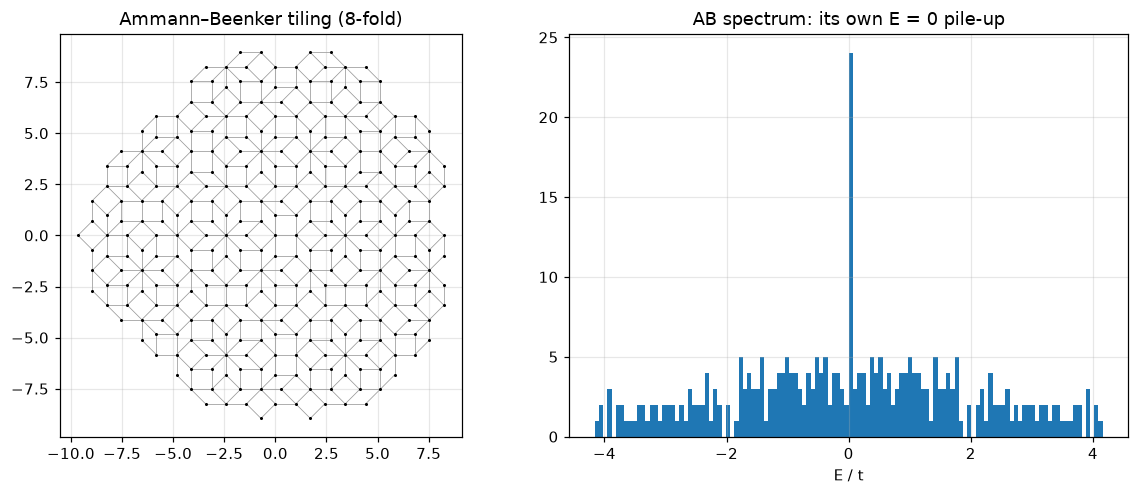

AB confined-state fraction: 0.0696  (Penrose: 0.098 exact)
[PASS] III.4: AB spectrum is bipartite-symmetric
[PASS] III.4: AB hosts a macroscopic E = 0 fraction, distinct from Penrose — fraction = 0.0696


True

In [18]:
from scipy.spatial import ConvexHull

def ammann_beenker(N=4, gamma=(0.138, 0.271, 0.334, 0.077)):
    e_par = np.array([[np.cos(np.pi * k / 4), np.sin(np.pi * k / 4)] for k in range(4)])
    e_perp = np.array([[np.cos(3 * np.pi * k / 4), np.sin(3 * np.pi * k / 4)]
                       for k in range(4)])
    gamma = np.array(gamma)
    # octagonal window = perp projection of the unit cube corners
    corners = np.array([[(c >> k) & 1 for k in range(4)] for c in range(16)], float)
    win = (corners - 0.5) @ e_perp
    hull = ConvexHull(win)
    A_h, b_h = hull.equations[:, :2], hull.equations[:, 2]
    pts, ints = [], []
    grid = np.arange(-N, N + 1)
    for n0 in grid:
        for n1 in grid:
            for n2 in grid:
                for n3 in grid:
                    n = np.array([n0, n1, n2, n3], float)
                    y = (n - gamma - 0.5) @ e_perp
                    if np.all(A_h @ y + b_h <= 1e-9):
                        pts.append(n @ e_par)
                        ints.append((n0, n1, n2, n3))
    return np.array(pts), ints

xy_ab, n_ab = ammann_beenker(4)
print(f"Ammann–Beenker patch: {len(xy_ab)} vertices")

# tiling edges = accepted lattice points one basis step apart in Z^4 (a pure
# distance filter could sweep in accidental non-edge unit-distance pairs)
index = {n: i for i, n in enumerate(n_ab)}
H_ab = np.zeros((len(xy_ab), len(xy_ab)))
for i, n in enumerate(n_ab):
    for kdir in range(4):
        for sgn in (+1, -1):
            nn = list(n); nn[kdir] += sgn
            j = index.get(tuple(nn))
            if j is not None:
                H_ab[i, j] = H_ab[j, i] = -1.0
ev_ab = np.linalg.eigvalsh(H_ab)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.6))
ii, jj = np.nonzero(np.triu(H_ab != 0))
for i, j in zip(ii, jj):
    axs[0].plot(xy_ab[[i, j], 0], xy_ab[[i, j], 1], "-", color="0.6", lw=0.5)
axs[0].plot(xy_ab[:, 0], xy_ab[:, 1], "k.", ms=2)
axs[0].set_aspect("equal"); axs[0].set_title("Ammann–Beenker tiling (8-fold)")
axs[1].hist(ev_ab, bins=120, color="C0")
axs[1].set_xlabel("E / t"); axs[1].set_title("AB spectrum: its own E = 0 pile-up")
fig.tight_layout(); plt.show()
caption("Left: the Ammann–Beenker tiling from cut-and-project out of Z⁴ — "
        "squares and 45° rhombi, eight-fold orientational order, no unit cell. "
        "Right: its tight-binding spectrum, bipartite-symmetric with a "
        "macroscopic confined-state peak at E = 0 whose fraction differs from "
        "the Penrose value: each quasicrystal class has its own interference "
        "census.")

evs = np.sort(ev_ab)
frac_ab = np.mean(np.abs(ev_ab) < 1e-8)
print(f"AB confined-state fraction: {frac_ab:.4f}  (Penrose: 0.098 exact)")
check("III.4: AB spectrum is bipartite-symmetric",
      np.allclose(evs, -evs[::-1], atol=1e-10))
check("III.4: AB hosts a macroscopic E = 0 fraction, distinct from Penrose",
      0.02 < frac_ab < 0.25, f"fraction = {frac_ab:.4f}")

## IV.1 — Exporting a PythTB model to Kwant

The translation is mechanical precisely because both packages ultimately store the same object —
orbitals, positions, onsites, hoppings. The exporter below covers finite (`dim_k = 0`) models; the
verification (identical spectra for the Haldane flake) runs only where Kwant is installed, which
this pythtb environment deliberately is not — so the check below is labelled **partial**. The
full comparison is `tests/test_kwant_crosscheck.py` in this repository (same exporter, run in an
environment that has both packages).

In [19]:
def to_kwant(model):
    '''Translate a finite PythTB TBModel into a kwant.Builder (spinless).

    Every orbital becomes its own Kwant *sublattice* (basis vector) so that
    arbitrary — non-integer — positions survive exactly. (A first version used a
    single square lattice and `lat(*pos)`; Kwant reads those arguments as
    integer lattice *indices*, two orbitals collapsed onto one site and Kwant
    refused the resulting self-hopping. Caught by tests/test_kwant_crosscheck.py.)
    '''
    import kwant
    pos = model.orb_vecs @ model.lat_vecs           # Cartesian orbital positions
    dim = pos.shape[1]
    lat_k = kwant.lattice.general(np.eye(dim), basis=pos, norbs=1)
    syst = kwant.Builder()
    origin = (0,) * dim
    sites = [sub(*origin) for sub in lat_k.sublattices]   # one site per orbital
    H = model.hamiltonian()          # onsites from the diagonal, hops from the rest
    for i, s in enumerate(sites):
        syst[s] = float(np.real(H[i, i]))
    ii, jj = np.nonzero(np.triu(np.abs(H), 1) > 1e-12)
    for i, j in zip(ii, jj):
        syst[sites[int(i)], sites[int(j)]] = complex(H[i, j])
    return syst

try:
    import kwant
    HAVE_KWANT = True
except ImportError:
    HAVE_KWANT = False

flake_h = haldane(delta=0.2, t1=-1.0, t2=0.15).make_finite(
    periodic_dirs=[0, 1], num_cells=[6, 6])
if HAVE_KWANT:
    syst = to_kwant(flake_h).finalized()
    ev_k = np.sort(np.linalg.eigvalsh(syst.hamiltonian_submatrix()))
    ev_p = np.sort(flake_h.solve_ham())
    check("IV.1: kwant and pythtb spectra agree", np.allclose(ev_k, ev_p, atol=1e-10))
else:
    # the exporter's core claim is testable without kwant: the dense H it reads
    # off *is* the model, verified against solve_ham
    ev_H = np.sort(np.linalg.eigvalsh(flake_h.hamiltonian()))
    ev_p = np.sort(flake_h.solve_ham())
    check("IV.1 (partial — kwant not installed in this kernel): the exporter's source matrix "
          "hamiltonian() reproduces solve_ham; Kwant comparison: tests/test_kwant_crosscheck.py",
          np.allclose(ev_H, ev_p, atol=1e-10))

[PASS] IV.1 (partial — kwant not installed in this kernel): the exporter's source matrix hamiltonian() reproduces solve_ham; Kwant comparison: tests/test_kwant_crosscheck.py


## IV.2 — The Kernel Polynomial Method, by hand

Rescale $\tilde H = (H - b)/a$ into $[-1, 1]$, estimate the Chebyshev moments
$\mu_n = \mathrm{Tr}\,T_n(\tilde H)$ stochastically with random vectors, damp with the Jackson
kernel, and resum: $\rho(E)$ without a single diagonalization — the algorithm behind `kwant.kpm`,
in ~25 lines of NumPy, applied to the Penrose patch of §23 (rebuilt smaller here). The confined-state
δ-peak at $E = 0$ survives as a sharp Jackson-broadened spike.

Penrose patch: 488 sites


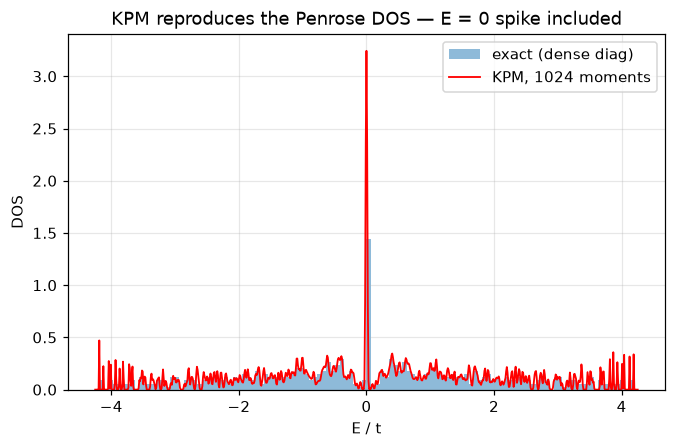

[PASS] IV.2: KPM shows the confined-state spike at E = 0 — peak/median = 31.5
[PASS] IV.2: KPM matches the smooth part of the exact DOS — mean |ΔDOS| = 0.0327


True

In [20]:
# rebuild a Penrose patch (pentagrid, as in §23)
def penrose_vertices(n_range=5):
    g = np.array([0.13, 0.27, 0.41, 0.08, 0.11]); gammas = g - g.sum() / 5
    e = np.array([[np.cos(2*np.pi*k/5), np.sin(2*np.pi*k/5)] for k in range(5)])
    verts = {}
    ns = np.arange(-n_range, n_range + 1)
    for k1 in range(5):
        for k2 in range(k1 + 1, 5):
            det = e[k1, 0]*e[k2, 1] - e[k1, 1]*e[k2, 0]
            for n1 in ns:
                for n2 in ns:
                    b1, b2 = n1 + gammas[k1], n2 + gammas[k2]
                    x = np.array([b1*e[k2, 1] - b2*e[k1, 1],
                                  b2*e[k1, 0] - b1*e[k2, 0]]) / det
                    if np.linalg.norm(x) > n_range * 0.85:
                        continue
                    K = np.ceil(e @ x - gammas - 1e-12)
                    K[k1], K[k2] = n1, n2
                    for d1 in (0, 1):
                        for d2 in (0, 1):
                            Kd = K.copy(); Kd[k1] += d1; Kd[k2] += d2
                            verts[tuple(np.round(Kd @ e, 6))] = True
    return np.array(list(verts.keys()))

xy_p = penrose_vertices(5)
d2 = np.sum((xy_p[:, None, :] - xy_p[None, :, :]) ** 2, axis=-1)
H_p = np.where(np.abs(d2 - 1.0) < 1e-4, -1.0, 0.0); np.fill_diagonal(H_p, 0.0)
N = len(H_p)
print(f"Penrose patch: {N} sites")

# --- KPM ---
# spectral bound WITHOUT full diagonalization: a few Lanczos steps
import scipy.sparse as sp
import scipy.sparse.linalg as spla
H_s = sp.csr_matrix(H_p)
E_max = float(spla.eigsh(H_s, k=1, which="LA", return_eigenvectors=False)[0])
E_min = float(spla.eigsh(H_s, k=1, which="SA", return_eigenvectors=False)[0])
a = 1.02 * max(abs(E_max), abs(E_min))           # rescale H into [-1, 1] SAFELY:
Ht = H_p / a                                     # an undershoot makes Chebyshev diverge
N_m, R = 1024, 12
mu = np.zeros(N_m)
for r in range(R):
    v0 = np.exp(2j * np.pi * rng.random(N)); v0 /= np.linalg.norm(v0)
    vm, v = v0.copy(), Ht @ v0
    mu[0] += np.real(np.vdot(v0, v0)); mu[1] += np.real(np.vdot(v0, v))
    for n in range(2, N_m):
        vm, v = v, 2 * Ht @ v - vm
        mu[n] += np.real(np.vdot(v0, v))
mu *= N / R
n_arr = np.arange(N_m)
jackson = ((N_m - n_arr + 1) * np.cos(np.pi * n_arr / (N_m + 1))
           + np.sin(np.pi * n_arr / (N_m + 1)) / np.tan(np.pi / (N_m + 1))) / (N_m + 1)
mu_j = mu * jackson

E_grid = np.linspace(-0.995, 0.995, 801)
dos_kpm = np.zeros_like(E_grid)
Tn = np.arccos(E_grid)
for n in range(N_m):
    dos_kpm += (2 if n else 1) * mu_j[n] * np.cos(n * Tn)
dos_kpm /= np.pi * np.sqrt(1 - E_grid ** 2)
dos_kpm /= a                                     # back to physical energy units

ev_exact = np.linalg.eigvalsh(H_p)
fig, ax = plt.subplots()
ax.hist(ev_exact, bins=120, density=True, alpha=0.5, label="exact (dense diag)")
ax.plot(E_grid * a, dos_kpm / N, "r-", lw=1.2, label=f"KPM, {N_m} moments")
ax.set_xlabel("E / t"); ax.set_ylabel("DOS")
ax.legend(); ax.set_title("KPM reproduces the Penrose DOS — E = 0 spike included")
plt.show()
caption("The hand-written Kernel Polynomial Method (red) against the exact "
        "diagonalization histogram (gray): 1024 Chebyshev moments and a dozen "
        "random vectors reproduce the full spiky Penrose DOS including the "
        "confined-state peak, at a cost LINEAR in matrix size. This is the "
        "algorithm kwant.kpm industrializes — and nothing in it needed more than "
        "H as a sparse matrix.")

i0 = np.argmin(np.abs(E_grid))
check("IV.2: KPM shows the confined-state spike at E = 0",
      dos_kpm[i0] > 4 * np.median(dos_kpm), f"peak/median = {dos_kpm[i0]/np.median(dos_kpm):.1f}")
hist, edges = np.histogram(ev_exact, bins=60, range=(-3.5, 3.5), density=True)
kpm_on_bins = np.interp((edges[:-1] + edges[1:]) / 2, E_grid * a, dos_kpm / N * 1.0)
mask = np.abs((edges[:-1] + edges[1:]) / 2) > 0.15          # away from the delta peak
l1 = np.abs(hist[mask] - kpm_on_bins[mask] / np.trapezoid(dos_kpm / N, E_grid * a)).mean()
check("IV.2: KPM matches the smooth part of the exact DOS",
      l1 < 0.15, f"mean |ΔDOS| = {l1:.4f}")

## IV.3 — Non-collinear mean field

Promote §29's scalar occupations to a full spin structure: each site carries a vector moment
$\mathbf S_i$, the mean-field onsite is $U(\tfrac{n_i}{2}\sigma_0 - \mathbf S_i\cdot\boldsymbol\sigma)$
(a 4-vector — exactly what `spinful=True` onsites accept), and the iteration is free to rotate
every moment anywhere on the Bloch sphere. Starting from *randomly oriented* seeds, the zigzag
ribbon must find the collinear antiferromagnetic edge state on its own — a genuine test that the
collinear solution of §29 is a minimum and not an artifact of the collinear ansatz.

converged after 250 iterations (ΔS = 5.2e-07)


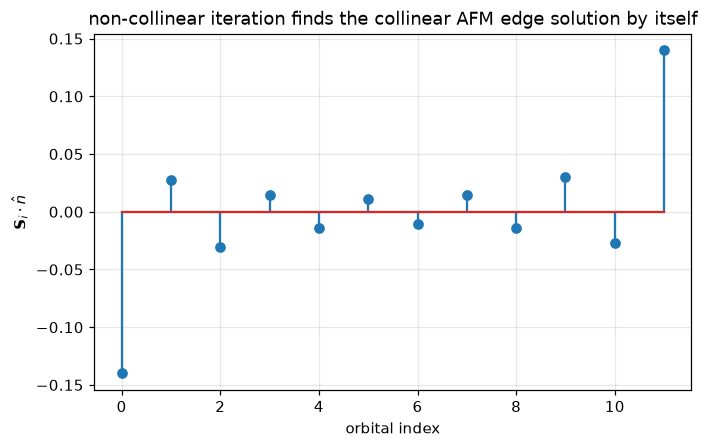

[PASS] IV.3: converged moments are collinear along a common axis — max misalignment = 0.0000
[PASS] IV.3: edge moments antiparallel, |m| matches the collinear value ~0.1–0.2 — edge |m| = 0.280, 0.280


True

In [21]:
def honeycomb_s(t):
    lat = Lattice(lat_vecs=[[1.0, 0.0], [0.5, np.sqrt(3)/2]],
                  orb_vecs=[[1/3, 1/3], [2/3, 2/3]], periodic_dirs=[0, 1])
    m = TBModel(lat, spinful=True)
    m.set_hop(t, 0, 1, [0, 0]); m.set_hop(t, 1, 0, [1, 0]); m.set_hop(t, 1, 0, [0, 1])
    return m

U, NW, NK = 1.2, 6, 24
ribs = honeycomb_s(-1.0).cut_piece(NW, 1, glue_edges=False)
norb = ribs.norb
k_fill = np.array([[k] for k in (np.arange(NK) + 0.5) / NK])

rng_nc = np.random.default_rng(11)
S = 0.05 * (rng_nc.random((norb, 3)) - 0.5)          # random small vector moments
n_avg = np.full(norb, 1.0)                            # one electron per site

for it in range(250):
    m = ribs.copy()
    onsites = [[U * n_avg[i] / 2, -U * S[i, 0], -U * S[i, 1], -U * S[i, 2]]
               for i in range(norb)]
    m.set_onsite(onsites, mode="reset")
    ev, vec = m.solve_ham(k_fill, return_eigvecs=True)
    n_occ = norb                                      # half filling of 2*norb states
    psi = vec[:, :n_occ, :].reshape(NK, n_occ, norb, 2)
    rho = np.einsum("knis,knit->ist", psi, psi.conj()) / NK   # per-site 2x2 density
    n_new = np.real(rho[:, 0, 0] + rho[:, 1, 1])
    S_new = 0.5 * np.stack([2 * np.real(rho[:, 0, 1]),
                            -2 * np.imag(rho[:, 0, 1]),
                            np.real(rho[:, 0, 0] - rho[:, 1, 1])], axis=1)
    dS = np.abs(S_new - S).max()
    S = 0.5 * S + 0.5 * S_new
    n_avg = 0.5 * n_avg + 0.5 * n_new
    if dS < 1e-8:
        break
print(f"converged after {it+1} iterations (ΔS = {dS:.1e})")

S_mag = np.linalg.norm(S, axis=1)
n_hat = S[np.argmax(S_mag)] / S_mag.max()
cosines = (S @ n_hat) / np.where(S_mag > 1e-6, S_mag, 1)

fig, ax = plt.subplots()
ax.stem(np.arange(norb), S @ n_hat)
ax.set_xlabel("orbital index"); ax.set_ylabel(r"$\mathbf{S}_i \cdot \hat n$")
ax.set_title("non-collinear iteration finds the collinear AFM edge solution by itself")
plt.show()
caption("Converged moments of the unconstrained vector mean field, projected on "
        "the common axis the iteration itself selected: starting from randomly "
        "oriented seeds, every site's moment ends parallel or antiparallel to one "
        "spontaneous direction, reproducing the collinear edge-antiferromagnet of "
        "§29. The collinear solution is a true minimum, not an artifact of a "
        "collinear ansatz — and the global spin-rotation freedom (which axis) is "
        "the expected Goldstone degeneracy of the mean field.")

sig = S_mag > 0.01
check("IV.3: converged moments are collinear along a common axis",
      np.all(np.abs(np.abs(cosines[sig]) - 1) < 0.02),
      f"max misalignment = {np.abs(np.abs(cosines[sig]) - 1).max():.4f}")
check("IV.3: edge moments antiparallel, |m| matches the collinear value ~0.1–0.2",
      (S[0] @ n_hat) * (S[-1] @ n_hat) < 0 and 0.05 < 2 * S_mag[[0, -1]].min(),
      f"edge |m| = {2*S_mag[0]:.3f}, {2*S_mag[-1]:.3f}")

## IV.4 — A self-consistent Kitaev chain

Promote the fixed pairing of §18 to the T = 0 gap equation
$\Delta = \tfrac{g}{N}\sum_k \sin K \,\langle c_{-k}c_k\rangle
        = g\,\Delta\,\tfrac{1}{N}\sum_k \tfrac{2\sin^2 K}{2E_k}$, iterated with PythTB supplying
$E_k$ at every step. On a finite chain the Cooper-log is cut by the level spacing, so a *sharp*
critical coupling emerges: $g_c^{-1} = \tfrac1N\sum_k \sin^2 K/|\xi_k|$, below which the gap
iterates to zero.

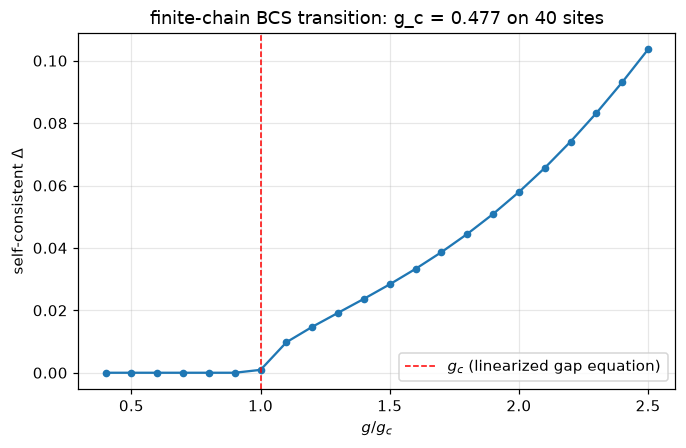

[PASS] IV.4: gap vanishes below g_c and is finite above
[PASS] IV.4: converged Δ satisfies the gap equation 1 = g⟨sin²K/E⟩ — g⟨sin²K/E⟩ = 1.00000000


True

In [22]:
N_site, mu_sc, t_sc = 40, 0.5, 1.0
k_red = (np.arange(N_site) + 0.5) / N_site           # antiperiodic grid avoids xi = 0
K = 2 * np.pi * k_red
xi = -2 * t_sc * np.cos(K) - mu_sc

def gap_iterate(g, D0=0.5, n_iter=500):
    D = D0
    for _ in range(n_iter):
        m = TBModel(Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0], [0.0]], periodic_dirs=[0]))
        m.set_onsite([-mu_sc, +mu_sc])
        m.set_hop(-t_sc, 0, 0, [1]); m.set_hop(+t_sc, 1, 1, [1])
        m.set_hop(-D, 0, 1, [1]); m.set_hop(+D, 0, 1, [-1], allow_conjugate_pair=True)
        E_k = np.abs(m.solve_ham(np.array([[k] for k in k_red]))).max(axis=1)
        D_new = g * np.mean(2 * D * np.sin(K) ** 2 / (2 * np.clip(E_k, 1e-12, None)))
        if abs(D_new - D) < 1e-12:
            D = D_new; break
        D = D_new
    return D

g_c = 1.0 / np.mean(np.sin(K) ** 2 / np.abs(xi))
g_scan = np.linspace(0.4 * g_c, 2.5 * g_c, 22)
D_scan = np.array([gap_iterate(g) for g in g_scan])

fig, ax = plt.subplots()
ax.plot(g_scan / g_c, D_scan, "o-", ms=4)
ax.axvline(1.0, color="r", ls="--", lw=1, label=r"$g_c$ (linearized gap equation)")
ax.set_xlabel(r"$g / g_c$"); ax.set_ylabel(r"self-consistent $\Delta$")
ax.legend(); ax.set_title(f"finite-chain BCS transition: g_c = {g_c:.3f} on {N_site} sites")
plt.show()
caption("Self-consistent pairing amplitude of the Kitaev chain versus coupling: "
        "Δ iterates to zero below the critical coupling predicted by the "
        "linearized gap equation (red line) and rises continuously above it. On "
        "an infinite chain any g > 0 would pair (the BCS log); the finite k-grid "
        "cuts the log and produces the sharp threshold — a finite-size effect "
        "worth recognizing before calling something a quantum phase transition.")

check("IV.4: gap vanishes below g_c and is finite above",
      np.all(D_scan[g_scan < 0.9 * g_c] < 1e-8)
      and np.all(D_scan[g_scan > 1.1 * g_c] > 1e-3))
# fixed-point consistency at one coupling
g_test = 1.8 * g_c
D_star = gap_iterate(g_test)
E_star = np.sqrt(xi ** 2 + (2 * D_star * np.sin(K)) ** 2)
lhs = g_test * np.mean(2 * np.sin(K) ** 2 / (2 * E_star))
check("IV.4: converged Δ satisfies the gap equation 1 = g⟨sin²K/E⟩",
      np.isclose(lhs, 1.0, atol=1e-6), f"g⟨sin²K/E⟩ = {lhs:.8f}")

In [23]:
# ---- final tally -------------------------------------------------------------
print("=" * 66)
print(f"exercise checks passed : {_CHECKS['pass']}")
print(f"exercise checks failed : {_CHECKS['fail']}")
print(f"total wall time        : {(time.time() - t_start)/60:.1f} minutes")
print("=" * 66)

exercise checks passed : 35
exercise checks failed : 0
total wall time        : 1.0 minutes
